### Motor Fault Detection Model


- **Dataset:** 23,000+ simulated motor records
- **Goal:** Train a high-accuracy classifier to detect EMPTY_RUN, STALLED, NORMAL, OFF
- **Export:** ONNX model (perfect for Node.js backend with onnxruntime-node)
- **Includes:** Full EDA, graphs, feature engineering, evaluation, model saving

In [1]:
# === INSTALL REQUIRED PACKAGES ===
!pip install pandas scikit-learn seaborn matplotlib xgboost skl2onnx onnxruntime joblib --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# === IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import joblib
import json
import onnxruntime as ort
from datetime import datetime

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


In [5]:
HEADERS = [
    "timestamp",
    "motor_id",
    "rpm",
    "vibration_hz",
    "current_amp",
    "temperature_c",
    "power_factor",
    "state",
    "status",
    "alert_code",
]

df = pd.read_csv(
    "../dataset/motor_dataset.csv",
    header=None,      # CSV has no header row
    names=HEADERS     # assign your column names
)

# Optional cleanup in case of whitespace/casing issues
df["state"] = df["state"].astype(str).str.strip()

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("First 3 rows:")
display(df.head(3))
print("Target distribution:")
print(df["state"].value_counts(normalize=True) * 100)

Shape: (25981, 10)
Columns: ['timestamp', 'motor_id', 'rpm', 'vibration_hz', 'current_amp', 'temperature_c', 'power_factor', 'state', 'status', 'alert_code']
First 3 rows:


,timestamp,motor_id,rpm,vibration_hz,current_amp,temperature_c,power_factor,state,status,alert_code
0,1.776564e+09,MTR-001,1488.4,61.69,15.15,48.0,0.839,NORMAL,HEALTHY,0
1,1.776564e+09,MTR-001,1490.2,59.98,15.53,48.0,0.887,NORMAL,HEALTHY,0
2,1.776564e+09,MTR-001,1475.0,59.17,15.33,48.1,0.904,NORMAL,HEALTHY,0


Target distribution:
state
NORMAL       93.487549
EMPTY_RUN     5.207652
STALLED       1.304800
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)

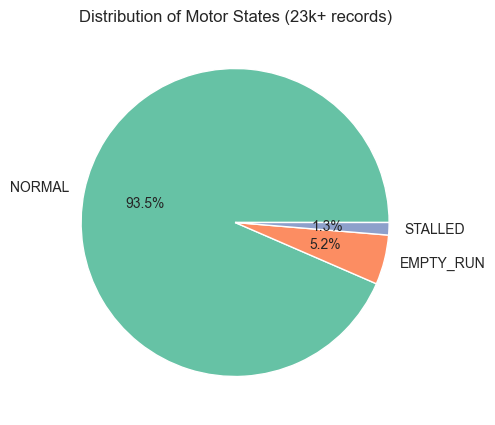

In [6]:
# State distribution
plt.figure(figsize=(10,5))
df['state'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Distribution of Motor States (23k+ records)')
plt.ylabel('')
plt.show()

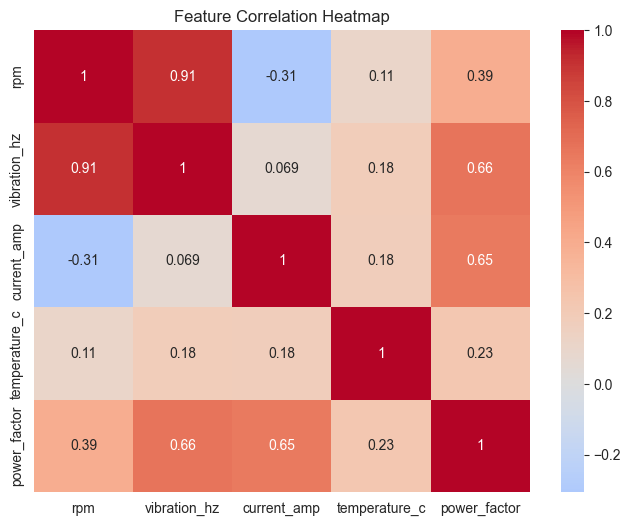

In [9]:
# Correlation heatmap
plt.figure(figsize=(8,6))
numeric_cols = ['rpm', 'vibration_hz', 'current_amp', 'temperature_c', 'power_factor']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

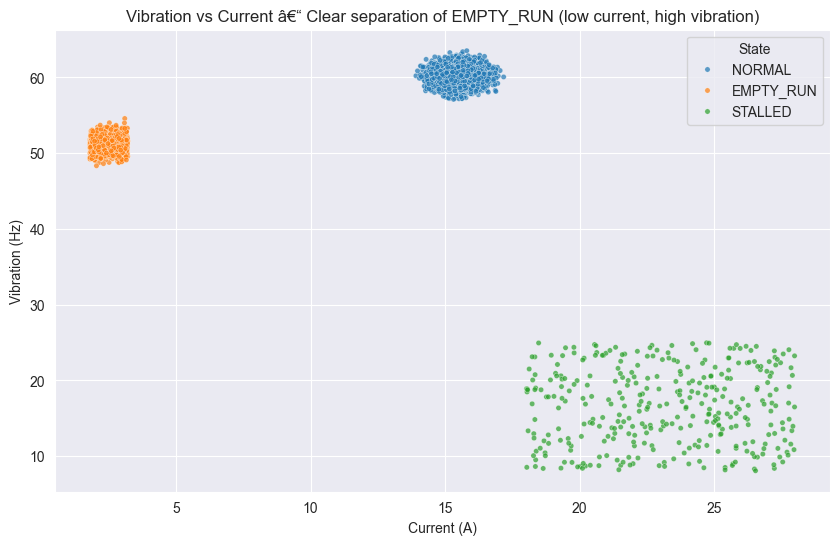

In [10]:
# Vibration vs Current (most important for Empty Run detection)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='current_amp', y='vibration_hz', hue='state', alpha=0.7, s=15)
plt.title('Vibration vs Current â€“ Clear separation of EMPTY_RUN (low current, high vibration)')
plt.xlabel('Current (A)')
plt.ylabel('Vibration (Hz)')
plt.legend(title='State')
plt.show()

C:\Users\rodra\AppData\Local\Temp\ipykernel_16440\1565352694.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='state', y=col, palette='Set2')
C:\Users\rodra\AppData\Local\Temp\ipykernel_16440\1565352694.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='state', y=col, palette='Set2')
C:\Users\rodra\AppData\Local\Temp\ipykernel_16440\1565352694.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='state', y=col, palette='Set2')
C:\Users\rodra\AppData\Local\Temp\ipykernel_16440\1565352694.py:6: FutureWarnin

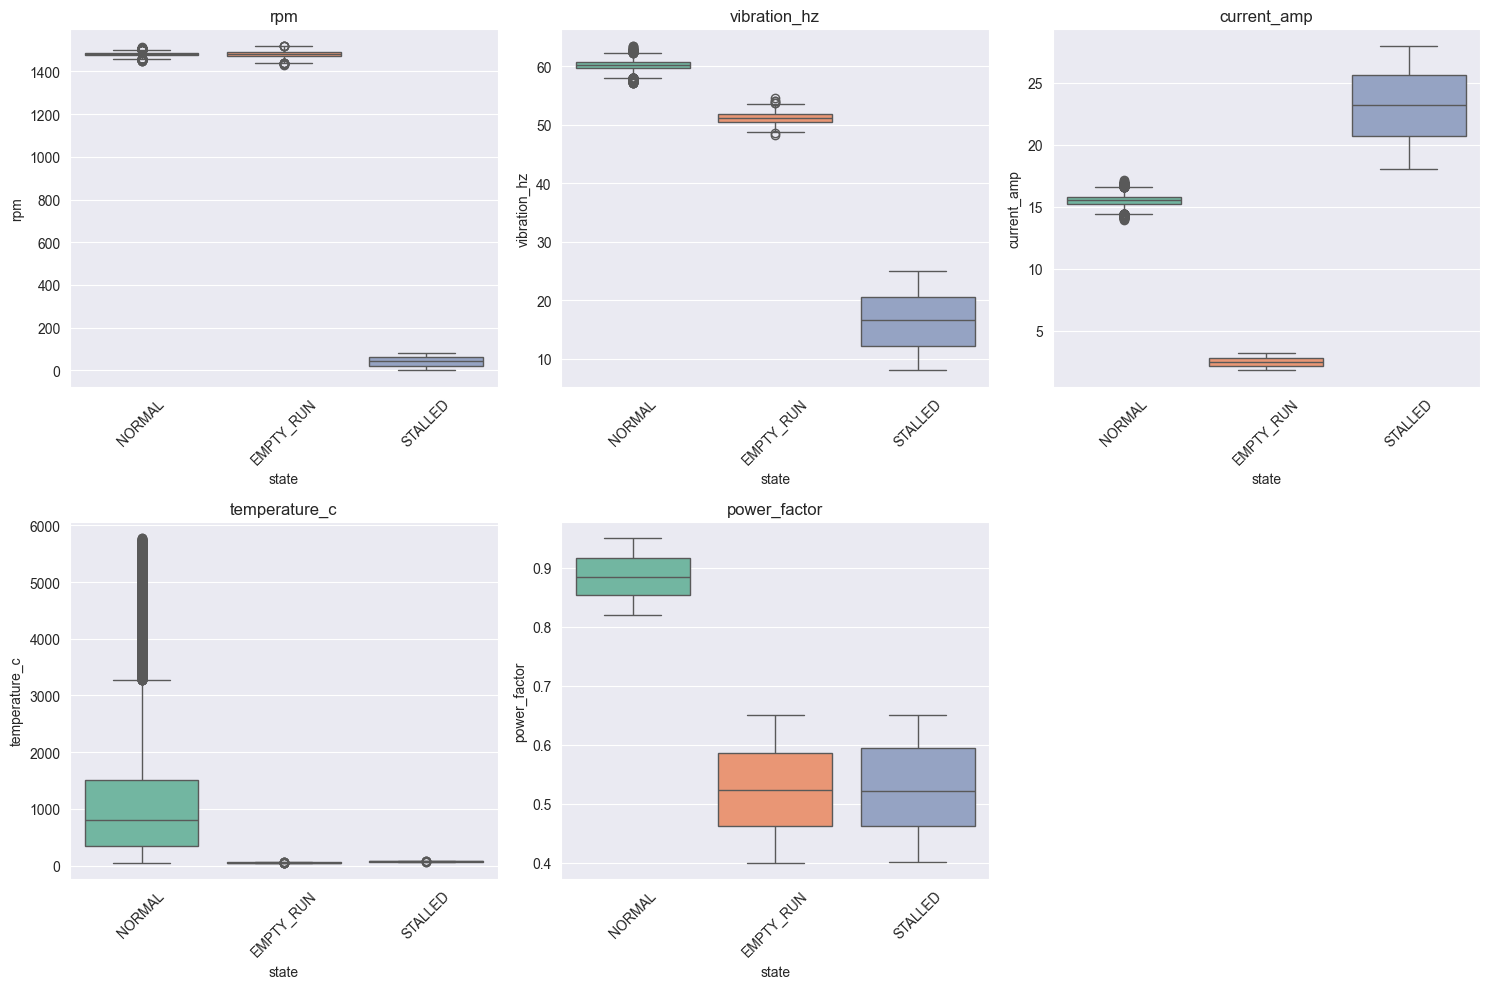

In [11]:
# Box plots â€“ how features differ per state
features = ['rpm', 'vibration_hz', 'current_amp', 'temperature_c', 'power_factor']
plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='state', y=col, palette='Set2')
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [12]:
# === FEATURE ENGINEERING (highly effective for this dataset) ===
df = df.copy()

df['vib_per_amp'] = df['vibration_hz'] / (df['current_amp'] + 0.1)
df['current_ratio'] = df['current_amp'] / 15.5
df['vibration_dev'] = abs(df['vibration_hz'] - 60.2)
df['temp_rise'] = df['temperature_c'] - 48.0
df['power_kw'] = df['current_amp'] * 230 * df['power_factor'] / 1000
df['high_current_low_rpm'] = ((df['current_amp'] > 22) & (df['rpm'] < 200)).astype(int)

print('Engineered features added. New shape:', df.shape)

Engineered features added. New shape: (25981, 16)


## 4. Prepare Training Data

In [13]:
feature_cols = [
    'rpm', 'vibration_hz', 'current_amp', 'temperature_c', 'power_factor',
    'vib_per_amp', 'current_ratio', 'vibration_dev', 'temp_rise', 'power_kw', 'high_current_low_rpm'
]

X = df[feature_cols]
y = df['state']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')

Train: 19,485 rows | Test: 6,496 rows


## 5. Train Random Forest (Best balance of speed & accuracy)

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print('âœ… Random Forest trained!')

âœ… Random Forest trained!


## 6. Evaluation & Charts

Classification Report:
              precision    recall  f1-score   support

   EMPTY_RUN     1.0000    1.0000    1.0000       338
      NORMAL     1.0000    1.0000    1.0000      6073
     STALLED     1.0000    1.0000    1.0000        85

    accuracy                         1.0000      6496
   macro avg     1.0000    1.0000    1.0000      6496
weighted avg     1.0000    1.0000    1.0000      6496



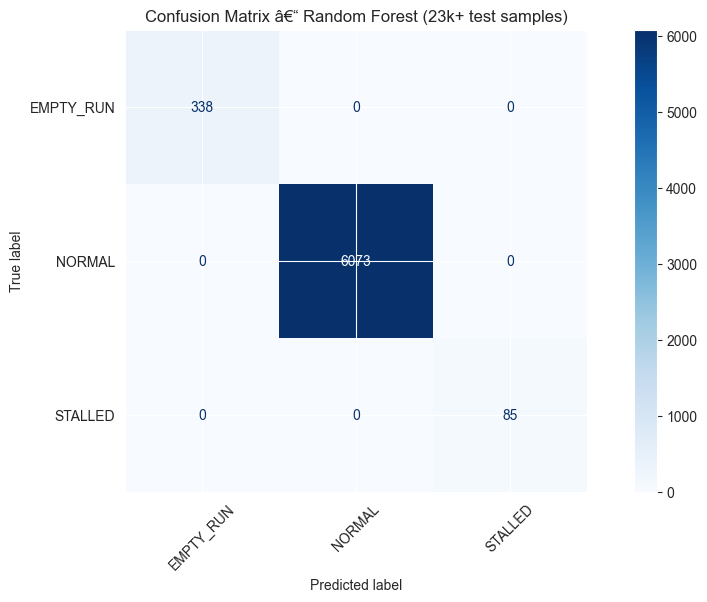

In [15]:
print('Classification Report:')
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix â€“ Random Forest (23k+ test samples)')
plt.show()

C:\Users\rodra\AppData\Local\Temp\ipykernel_16440\2476279032.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


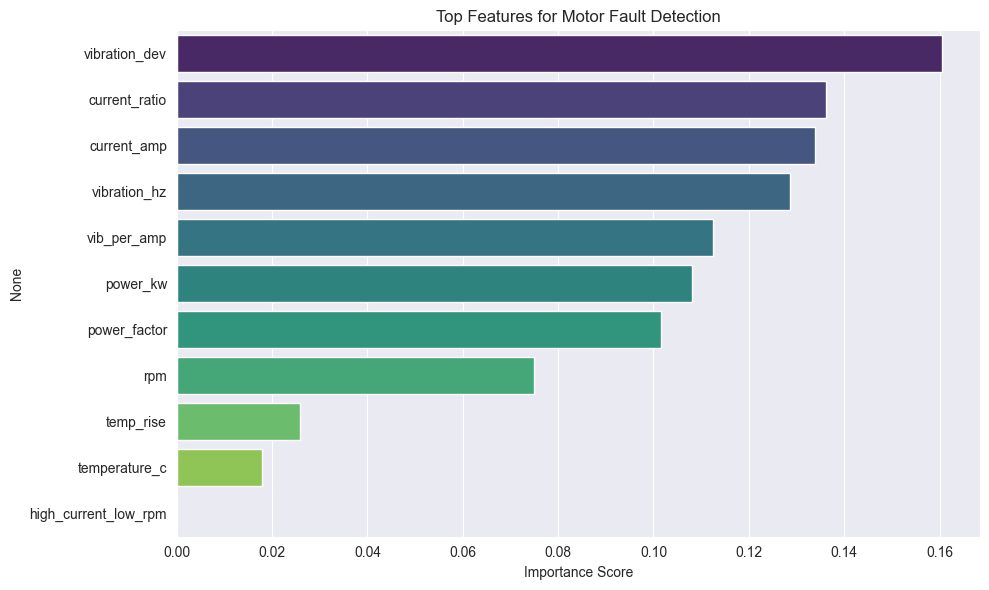

In [16]:
# Feature Importance
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top Features for Motor Fault Detection')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 7. (Optional) XGBoost â€“ Usually even higher accuracy

In [ ]:
# Uncomment to train XGBoost
# xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=12, learning_rate=0.1,
#                               subsample=0.9, colsample_bytree=0.8, random_state=42)
# xgb_model.fit(X_train, y_train)
# print('XGBoost accuracy on test:', xgb_model.score(X_test, y_test))

## 8. Save Models

In [17]:
# 1. Save as Joblib (for Python)
joblib.dump(rf_model, 'motor_fault_rf_model.pkl')
print('âœ… Saved: motor_fault_rf_model.pkl')

# 2. Save as ONNX (for Node.js backend)
initial_type = [('float_input', FloatTensorType([None, len(feature_cols)]))]
onnx_model = convert_sklearn(rf_model, initial_types=initial_type, target_opset=13)

with open('motor_fault_model.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

print('âœ… Saved: motor_fault_model.onnx  â† Use this in Node.js!')

# Also save feature list for Node.js
with open('feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)
print('âœ… Saved: feature_columns.json')

âœ… Saved: motor_fault_rf_model.pkl
âœ… Saved: motor_fault_model.onnx  â† Use this in Node.js!
âœ… Saved: feature_columns.json


## 9. Test ONNX inference in notebook (same as Node.js)

In [18]:
sess = ort.InferenceSession('motor_fault_model.onnx')
input_name = sess.get_inputs()[0].name

# Test on one sample
sample = X_test.iloc[0:1].values.astype(np.float32)
pred_onnx = sess.run(None, {input_name: sample})[0]

print('ONNX prediction:', pred_onnx[0])
print('True label:', y_test.iloc[0])

ONNX prediction: NORMAL
True label: NORMAL
